In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cpu
CUDA available: False
Using device: cpu


## Optimization intuition

Training means:
- make predictions
- measure error with a loss function
- compute gradients
- update parameters to reduce loss

The optimizer decides how the parameters move.

 Create a simple regression dataset

 We will learn:
y = 2x + 1
with some noise

In [2]:
torch.manual_seed(42)

X = torch.linspace(-5, 5, 200).reshape(-1,1)
noise = 0.8 * torch.randn_like(X)
Y = 2 * X + 1 + noise

print(X.shape, Y.shape)
print(X[:5])
print(Y[:5])

torch.Size([200, 1]) torch.Size([200, 1])
tensor([[-5.0000],
        [-4.9497],
        [-4.8995],
        [-4.8492],
        [-4.7990]])
tensor([[ -7.4585],
        [ -7.7097],
        [ -8.0784],
        [-10.3829],
        [ -8.0553]])


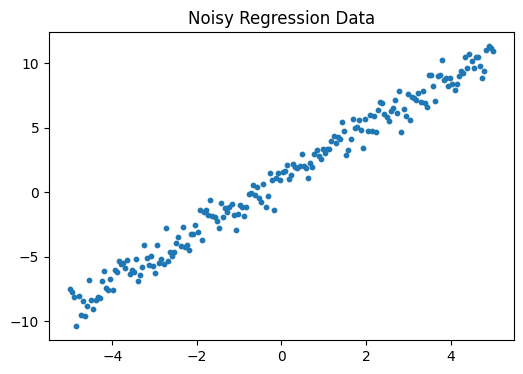

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10)
plt.title("Noisy Regression Data")
plt.show()

## Define a simple model

In [5]:
model = nn.Linear(1,1)
print("initial weight:", model.weight.item())
print("initial bias:", model.bias.item())
print(model)


initial weight: 0.4137152433395386
initial bias: -0.38088154792785645
Linear(in_features=1, out_features=1, bias=True)


In [6]:
# Loss function
criterion = nn.MSELoss()


In [7]:
# First optimizer: SGD
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [8]:
loss_history_sgd =[]

for epoch in range(200):
  preds = model(X)
  loss = criterion(preds, Y)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  loss_history_sgd.append(loss.item())

  if epoch % 20 == 0:
    print(f"Epoch{epoch:03d} | Loss:{loss.item():.5f}")

Epoch000 | Loss:23.44132
Epoch020 | Loss:1.52189
Epoch040 | Loss:1.01232
Epoch060 | Loss:0.79102
Epoch080 | Loss:0.69238
Epoch100 | Loss:0.64842
Epoch120 | Loss:0.62883
Epoch140 | Loss:0.62010
Epoch160 | Loss:0.61621
Epoch180 | Loss:0.61447


In [9]:
print("learned weight:", model.weight.item())
print("learned bias:", model.bias.item())

learned weight: 1.986407995223999
learned bias: 1.0118354558944702


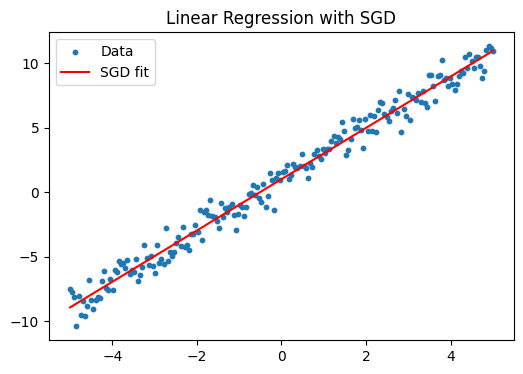

In [10]:
with torch.no_grad():
  preds_sgd = model(X)

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10, label="Data")
plt.plot(X.numpy(), preds_sgd.numpy(), color="red", label="SGD fit")
plt.legend()
plt.title("Linear Regression with SGD")
plt.show()


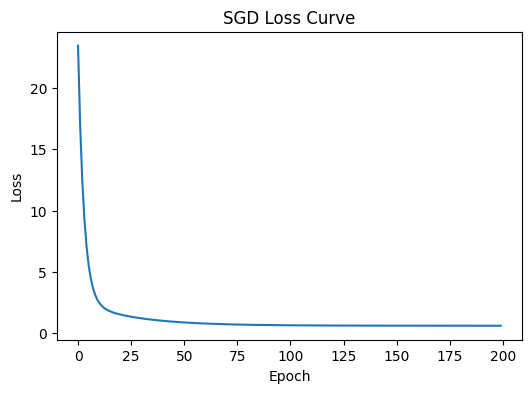

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history_sgd)
plt.title("SGD Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Compare with Adam

In [12]:
torch.manual_seed(42)

model_adam = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.01)

In [13]:
loss_history_adam = []

for epoch in range(200):
    preds = model_adam(X)
    loss = criterion(preds, Y)

    optimizer_adam.zero_grad()
    loss.backward()
    optimizer_adam.step()

    loss_history_adam.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

Epoch 000 | Loss: 13.222247
Epoch 020 | Loss: 9.439888
Epoch 040 | Loss: 6.517511
Epoch 060 | Loss: 4.384224
Epoch 080 | Loss: 2.910940
Epoch 100 | Loss: 1.944912
Epoch 120 | Loss: 1.345082
Epoch 140 | Loss: 0.993571
Epoch 160 | Loss: 0.799718
Epoch 180 | Loss: 0.699324


In [14]:
print("learned weight:", model_adam.weight.item())
print("learned bias:", model_adam.bias.item())

learned weight: 1.9196698665618896
learned bias: 1.0367658138275146


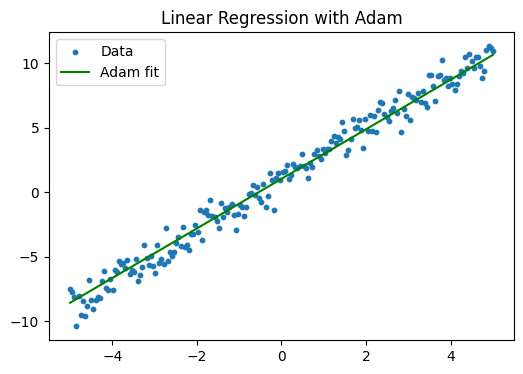

In [15]:
with torch.no_grad():
    preds_adam = model_adam(X)

plt.figure(figsize=(6, 4))
plt.scatter(X.numpy(), Y.numpy(), s=10, label="Data")
plt.plot(X.numpy(), preds_adam.numpy(), color="green", label="Adam fit")
plt.legend()
plt.title("Linear Regression with Adam")
plt.show()

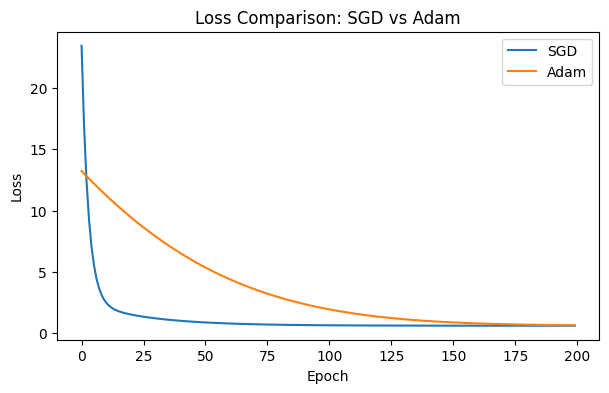

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history_sgd, label="SGD")
plt.plot(loss_history_adam, label="Adam")
plt.legend()
plt.title("Loss Comparison: SGD vs Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Learning rate matters

In [18]:
# Try a very small learning rate
torch.manual_seed(42)

model_small_lr = nn.Linear(1,1)
optimizer_small_lr = optim.SGD(model_small_lr.parameters(), lr=0.0001)
criterion = nn.MSELoss()

loss_history_small_lr = []

for epoch in range(200):
    preds = model_small_lr(X)
    loss = criterion(preds, Y)

    optimizer_small_lr.zero_grad()
    loss.backward()
    optimizer_small_lr.step()

    loss_history_small_lr.append(loss.item())

In [19]:
# Try a very large learning rate
torch.manual_seed(42)

model_large_lr = nn.Linear(1, 1)
optimizer_large_lr = optim.SGD(model_large_lr.parameters(), lr=1.0)
criterion = nn.MSELoss()

loss_history_large_lr = []

for epoch in range(200):
    preds = model_large_lr(X)
    loss = criterion(preds, Y)

    optimizer_large_lr.zero_grad()
    loss.backward()
    optimizer_large_lr.step()

    loss_history_large_lr.append(loss.item())

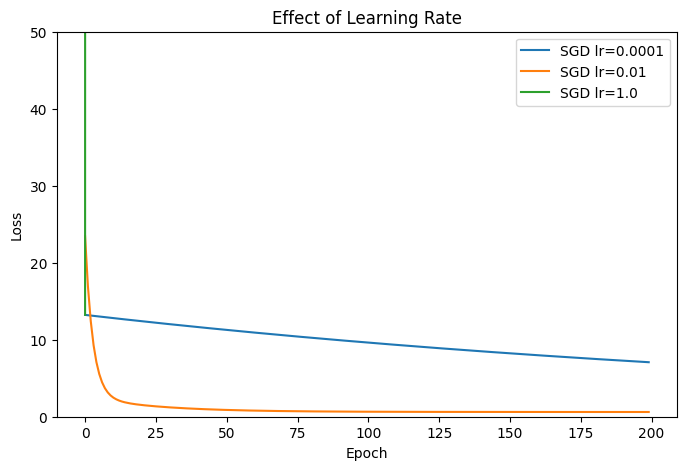

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history_small_lr, label="SGD lr=0.0001")
plt.plot(loss_history_sgd, label="SGD lr=0.01")
plt.plot(loss_history_large_lr, label="SGD lr=1.0")
plt.ylim(0, 50)
plt.legend()
plt.title("Effect of Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Deeper model: optimization is harder

In [21]:
torch.manual_seed(42)

X2 = torch.linspace(-2, 2, 200).reshape(-1, 1)
Y2 = X2**2

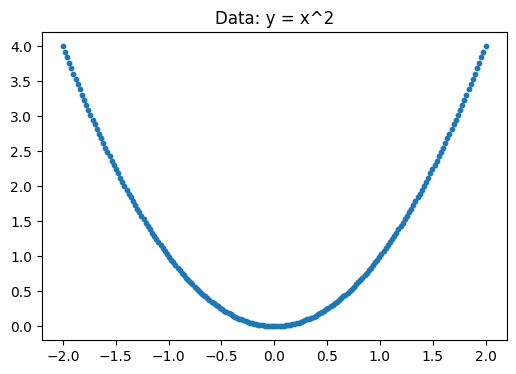

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(X2.numpy(), Y2.numpy(), s=10)
plt.title("Data: y = x^2")
plt.show()

In [27]:
# Define a deeper network

class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [28]:
model_deep = DeepMLP()
print(model_deep)

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [29]:
# Train deep model with Adam
model_deep = DeepMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_deep.parameters(), lr=0.01)

loss_history_deep = []

for epoch in range(1000):
    preds = model_deep(X2)
    loss = criterion(preds, Y2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history_deep.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:04d} | Loss: {loss.item():.6f}")

Epoch 0000 | Loss: 2.876560
Epoch 0100 | Loss: 0.003934
Epoch 0200 | Loss: 0.000382
Epoch 0300 | Loss: 0.000093
Epoch 0400 | Loss: 0.000037
Epoch 0500 | Loss: 0.000021
Epoch 0600 | Loss: 0.000014
Epoch 0700 | Loss: 0.000011
Epoch 0800 | Loss: 0.000009
Epoch 0900 | Loss: 0.000008


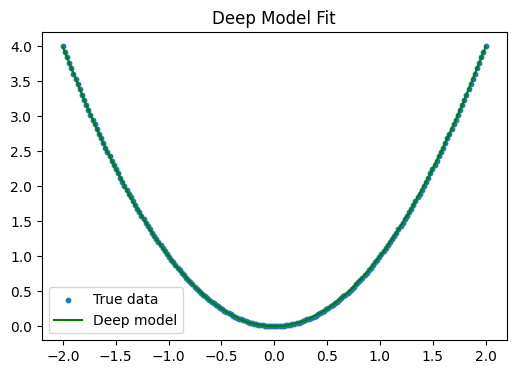

In [30]:
with torch.no_grad():
    preds_deep = model_deep(X2)

plt.figure(figsize=(6, 4))
plt.scatter(X2.numpy(), Y2.numpy(), s=10, label="True data")
plt.plot(X2.numpy(), preds_deep.numpy(), color="green", label="Deep model")
plt.legend()
plt.title("Deep Model Fit")
plt.show()

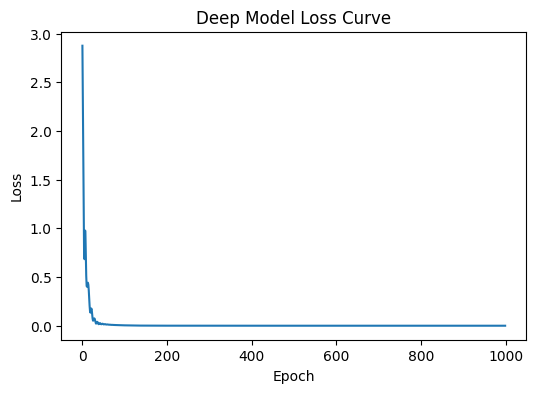

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history_deep)
plt.title("Deep Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Initialization matters

Weights are not just random decoration.
Bad initialization can make training harder.

We will compare:
- default initialization
- all zeros
- Xavier initialization



In [32]:
#  Helper function to train a model
def train_and_record(model, X, Y, epochs=300, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        preds = model(X)
        loss = criterion(preds, Y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return loss_history, model




In [33]:
# Default initialization
torch.manual_seed(42)
model_default = DeepMLP()
loss_default, trained_default = train_and_record(model_default, X2, Y2)

In [34]:
# Bad initialization: all zeros
torch.manual_seed(42)
model_zero = DeepMLP()

for name, param in model_zero.named_parameters():
    nn.init.zeros_(param)

loss_zero, trained_zero = train_and_record(model_zero, X2, Y2)

In [35]:
#  Xavier initialization

torch.manual_seed(42)
model_xavier = DeepMLP()

for module in model_xavier.modules():
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

loss_xavier, trained_xavier = train_and_record(model_xavier, X2, Y2)


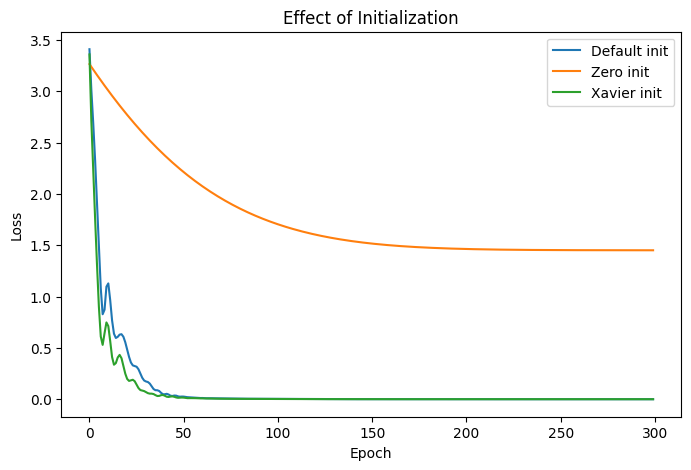

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(loss_default, label="Default init")
plt.plot(loss_zero, label="Zero init")
plt.plot(loss_xavier, label="Xavier init")
plt.legend()
plt.title("Effect of Initialization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

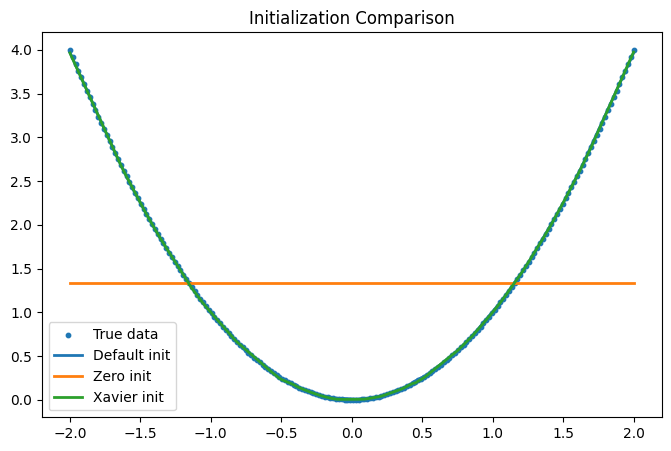

In [37]:
# Compare fitted curves
with torch.no_grad():
    preds_default = trained_default(X2)
    preds_zero = trained_zero(X2)
    preds_xavier = trained_xavier(X2)

plt.figure(figsize=(8, 5))
plt.scatter(X2.numpy(), Y2.numpy(), s=10, label="True data")
plt.plot(X2.numpy(), preds_default.numpy(), label="Default init", linewidth=2)
plt.plot(X2.numpy(), preds_zero.numpy(), label="Zero init", linewidth=2)
plt.plot(X2.numpy(), preds_xavier.numpy(), label="Xavier init", linewidth=2)
plt.legend()
plt.title("Initialization Comparison")
plt.show()

## Inspect parameter statistics - Production habit

In [42]:
for name, param in model_xavier.named_parameters():
    print(name, "mean =", param.data.mean().item(), "std =", param.data.std().item())

net.0.weight mean = -0.032066550105810165 std = 0.2926420569419861
net.0.bias mean = -0.09175295382738113 std = 0.11373402178287506
net.2.weight mean = -0.0016844191122800112 std = 0.2158464789390564
net.2.bias mean = -0.016013942658901215 std = 0.10842519998550415
net.4.weight mean = -0.013956543058156967 std = 0.20648452639579773
net.4.bias mean = -0.038691822439432144 std = 0.06347985565662384
net.6.weight mean = 0.06402776390314102 std = 0.245522141456604
net.6.bias mean = 0.06538547575473785 std = nan


/tmp/ipykernel_4358/3856845605.py:2: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  print(name, "mean =", param.data.mean().item(), "std =", param.data.std().item())


In [44]:
# Save trained weights
torch.save(model_xavier.state_dict(), "deep_model_initialized.pth")
print("model saved")

model saved
